In [2]:
from pathlib import Path
import numpy as np
import xarray as xr
import xclimate as xclim
import matplotlib.pyplot as plt

In [15]:
def compute_aridity_index(
    precip: np.ndarray | xr.DataArray,
    pet: np.ndarray | xr.DataArray,
    clip: bool = False,
) -> np.ndarray | xr.DataArray:
    """Compute the annual mean aridity index."""
    if clip:
        pet = pet.clip(min=0)
    ai = precip / pet
    return ai


def compute_inverse_aridity_index(
    precip: np.ndarray | xr.DataArray,
    pet: np.ndarray | xr.DataArray,
    clip: bool = False,
) -> np.ndarray | xr.DataArray:
    """Compute the annual mean inverse aridity index."""
    if clip:
        pet = pet.clip(min=0)
    inv_ai = pet / precip
    return inv_ai

In [59]:
pr = np.linspace(0, 200, 50)
pet = np.linspace(0, 300, 50)

pr2, pet2 = np.meshgrid(pr, pet)

In [64]:
ai = compute_aridity_index(pr2, pet2, clip=True)
ai_inv = compute_inverse_aridity_index(pr2, pet2, clip=True)

/glade/derecho/scratch/bbuchovecky/tmp/ipykernel_94041/559812832.py:9: RuntimeWarning: divide by zero encountered in divide
  ai = precip / pet
/glade/derecho/scratch/bbuchovecky/tmp/ipykernel_94041/559812832.py:9: RuntimeWarning: invalid value encountered in divide
  ai = precip / pet
/glade/derecho/scratch/bbuchovecky/tmp/ipykernel_94041/559812832.py:21: RuntimeWarning: divide by zero encountered in divide
  inv_ai = pet / precip
/glade/derecho/scratch/bbuchovecky/tmp/ipykernel_94041/559812832.py:21: RuntimeWarning: invalid value encountered in divide
  inv_ai = pet / precip


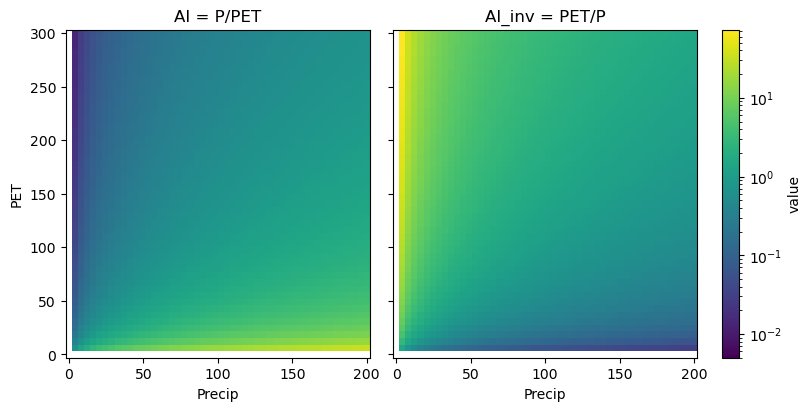

In [ ]:
from matplotlib.colors import LogNorm

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True, layout="constrained")
axs = axes.ravel()

plots = [
    ("AI = P/PET", ai),
    ("AI_inv = PET/P", ai_inv),
]

x = np.concat([ai, ai_inv])
vmax = x[np.isfinite(x)].max()
vmin = 5e-3

for ax, (title, data) in zip(axs, plots):
    data = np.ma.masked_where(~np.isfinite(data) | (data <= 0), data)
    im = ax.pcolormesh(pr, pet, data, norm=LogNorm(vmin=vmin, vmax=vmax))
    ax.set_title(title)

axs[0].set_ylabel("PET")
axs[0].set_xlabel("Precip")
axs[1].set_xlabel("Precip")

cb = fig.colorbar(im, ax=axs[1], orientation="vertical")
cb.set_label("value")

plt.show()

**Plot histogram of land area (or grid cells) in the PET-precip space to indicate where most AI values lie.**